In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer, MissingIndicator

from scipy.stats.mstats import winsorize

In [2]:
df = pd.read_csv('Dataset/patient_health_records.csv')
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,PAT0001,53.0,Male,North,26.3,137.2,193.4,138.0,1
1,PAT0002,31.0,Male,South,34.7,97.1,126.4,118.7,0
2,PAT0003,60.0,Male,South,32.0,121.9,219.7,144.3,1
3,PAT0004,63.0,Female,North,25.7,126.1,136.9,NaN,1
4,PAT0005,18.0,Female,North,30.8,117.5,205.8,NaN,1


## Missing Values

In [3]:
missing_summary = pd.DataFrame({
     'Missing count' : df.isna().sum(),
     'Missing percentage' : (df.isna().mean()*100).round(2)
    }).sort_values('Missing percentage', ascending = False)

In [4]:
missing_summary

,Missing count,Missing percentage
cholesterol,47,7.83
bmi,45,7.50
glucose,42,7.00
age,42,7.00
region,36,6.00
gender,30,5.00
patient_id,0,0.00
blood_pressure,0,0.00
disease_risk,0,0.00


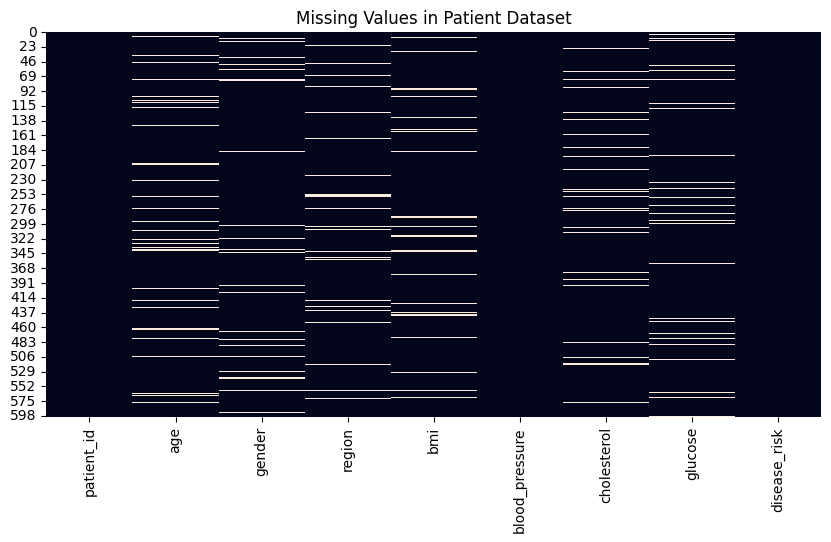

In [5]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Patient Dataset")
plt.show()

### Interpretation

The missing-value analysis shows which columns contain incomplete
records. These missing values need to be handled before applying
machine learning models because most ML algorithms cannot work
properly with missing values.

## PART - A Handling Missing Values

## Imputation

### Simple Imputer (Numerical)

In [6]:
df['bmi'].isnull().sum()

np.int64(45)

In [7]:
df_mean = df.copy()
mean_imputer = SimpleImputer(strategy = 'mean')

df_mean['bmi'] = mean_imputer.fit_transform(df_mean[['bmi']])
df_mean['bmi'].isna().sum()

np.int64(0)

### Simple Imputer (Categorical)

In [8]:
df['region'].isnull().sum()

np.int64(36)

In [9]:
df_categorical = df.copy()
cat_imputer = SimpleImputer(strategy='most_frequent')

df_categorical[['region']] = cat_imputer.fit_transform(df_categorical[['region']])
df_categorical['region'].isnull().sum()

np.int64(0)

## Most Frequent Imputation

In [10]:
df['gender'].isnull().sum()

np.int64(30)

In [11]:
df_most_frequent = df.copy()
gender_imputer = SimpleImputer(strategy='most_frequent')

df_most_frequent[['gender']] = gender_imputer.fit_transform(df_most_frequent[['gender']])
df_most_frequent['gender'].isnull().sum()

np.int64(0)

In [12]:
print("Most frequent region:", df['region'].mode()[0])
print("Most frequent gender:", df['gender'].mode()[0])

Most frequent region: South
Most frequent gender: Male


## Missing Indicator & Random sample Imputation

In [13]:
df_random = df.copy()

df_random['bmi_missing'] = df_random['bmi'].isnull().astype(int)
df_random['cholesterol_missing'] = df_random['cholesterol'].isnull().astype(int)
df_random['glucose_missing'] = df_random['glucose'].isnull().astype(int)
df_random.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,bmi_missing,cholesterol_missing,glucose_missing
0,PAT0001,53.0,Male,North,26.3,137.2,193.4,138.0,1,0,0,0
1,PAT0002,31.0,Male,South,34.7,97.1,126.4,118.7,0,0,0,0
2,PAT0003,60.0,Male,South,32.0,121.9,219.7,144.3,1,0,0,0
3,PAT0004,63.0,Female,North,25.7,126.1,136.9,NaN,1,0,0,1
4,PAT0005,18.0,Female,North,30.8,117.5,205.8,NaN,1,0,0,1


In [14]:
sample = df_random['bmi'].dropna().sample(df_random['bmi'].isna().sum(), random_state = 0)
df_random.loc[df_random['bmi'].isna(), 'bmi'] = sample.values

In [15]:
sample2 = df_random['cholesterol'].dropna().sample(df['cholesterol'].isna().sum(), random_state=0)
df_random.loc[df_random['cholesterol'].isna(), 'cholesterol'] = sample2.values

In [16]:
sample3 = df_random['glucose'].dropna().sample(df_random['glucose'].isna().sum(), random_state=0)
df_random.loc[df_random['glucose'].isna(), 'glucose'] = sample3.values

In [17]:
df_random.isna().sum()

patient_id              0
age                    42
gender                 30
region                 36
bmi                     0
blood_pressure          0
cholesterol             0
glucose                 0
disease_risk            0
bmi_missing             0
cholesterol_missing     0
glucose_missing         0
dtype: int64

## KNN Imputer

In [18]:
knn_data = df[['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']].copy()

knn_data.head()

,age,bmi,blood_pressure,cholesterol,glucose
0,53.0,26.3,137.2,193.4,138.0
1,31.0,34.7,97.1,126.4,118.7
2,60.0,32.0,121.9,219.7,144.3
3,63.0,25.7,126.1,136.9,NaN
4,18.0,30.8,117.5,205.8,NaN


In [19]:
knn_data.isna().sum()

age               42
bmi               45
blood_pressure     0
cholesterol       47
glucose           42
dtype: int64

In [20]:
knn_imputer = KNNImputer(n_neighbors=5)

knn_result = knn_imputer.fit_transform(knn_data)
knn_df = pd.DataFrame(knn_result,columns=knn_data.columns)
knn_df.head()

,age,bmi,blood_pressure,cholesterol,glucose
0,53.0,26.3,137.2,193.4,138.00
1,31.0,34.7,97.1,126.4,118.70
2,60.0,32.0,121.9,219.7,144.30
3,63.0,25.7,126.1,136.9,99.86
4,18.0,30.8,117.5,205.8,125.98


In [21]:
knn_df.isna().sum()

age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
dtype: int64

## MICE Algorithm

In [22]:
mice_data = df[['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']].copy()
mice_data.isna().sum()

age               42
bmi               45
blood_pressure     0
cholesterol       47
glucose           42
dtype: int64

In [23]:
mice_imputer = IterativeImputer(max_iter=10,random_state=42)
mice_result = mice_imputer.fit_transform(mice_data)

mice_df = pd.DataFrame(mice_result,columns=mice_data.columns)
mice_df.head()

,age,bmi,blood_pressure,cholesterol,glucose
0,53.0,26.3,137.2,193.4,138.000000
1,31.0,34.7,97.1,126.4,118.700000
2,60.0,32.0,121.9,219.7,144.300000
3,63.0,25.7,126.1,136.9,109.245701
4,18.0,30.8,117.5,205.8,109.273477


In [24]:
mice_df.isnull().sum()

age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
dtype: int64

## PART - B Handling Outliers

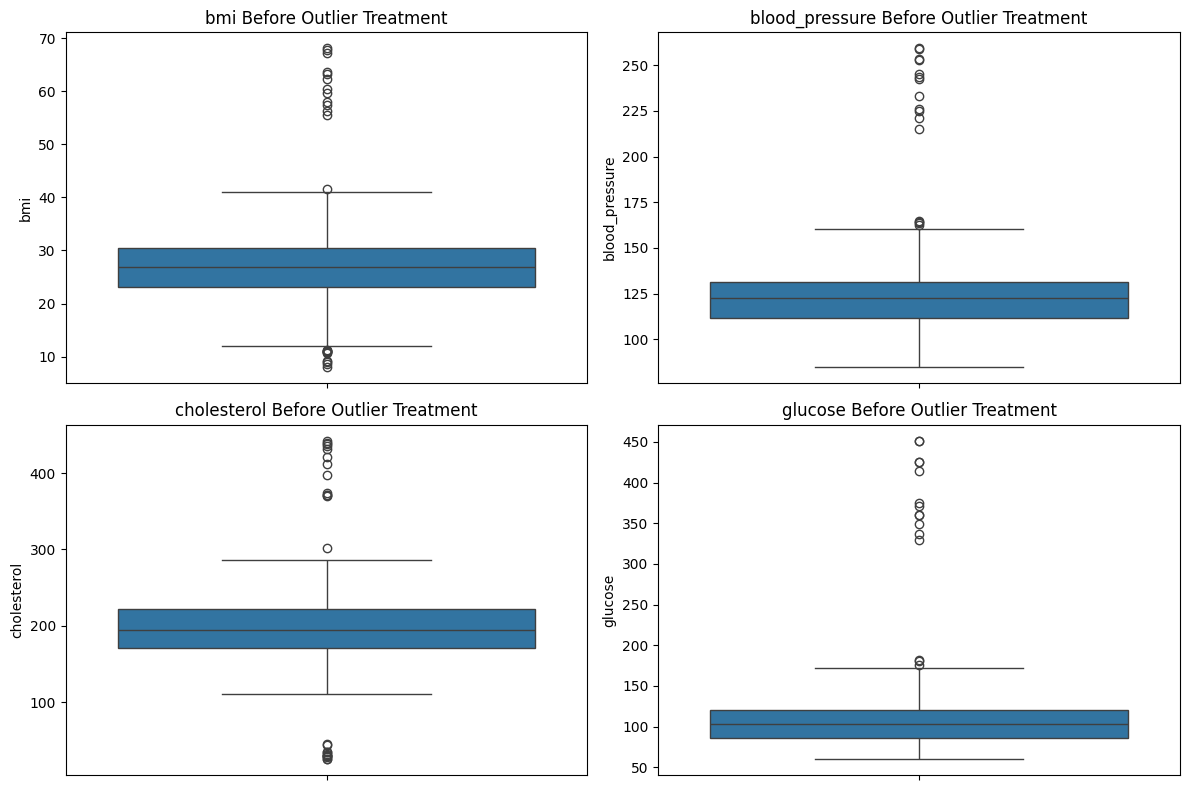

In [25]:
outlier_columns = ['bmi','blood_pressure','cholesterol','glucose']

plt.figure(figsize=(12, 8))

for i, col in enumerate(outlier_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'{col} Before Outlier Treatment')
plt.savefig("Box_plots.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### Interpretation

The boxplots show the distribution of BMI, blood pressure,
cholesterol and glucose.

Values appearing far away from the main box and whiskers are
potential outliers.

## Z-score method

In [26]:
df_zscore = df.copy()

zscore_columns = ['cholesterol', 'glucose']

In [27]:
for col in zscore_columns:

    mean = df_zscore[col].mean()
    std = df_zscore[col].std()

    z_scores = (df_zscore[col] - mean) / std

    df_zscore = df_zscore[(z_scores.abs() <= 3) | (df_zscore[col].isnull())]

In [28]:
print("Original Shape", df.shape)
print("After Z-score", df_zscore.shape)

Original Shape (600, 9)
After Z-score (566, 9)


## IQR Method

In [29]:
df_iqr = df.copy()

q1 = df_iqr['bmi'].quantile(0.25)
q3 = df_iqr['bmi'].quantile(0.75)

IQR = q3-q1

lower_fence = q1 - 1.5*IQR
upper_fence = q3 + 1.5*IQR

outlier_mask = (df_iqr['bmi'] < lower_fence) | (df_iqr['bmi'] > upper_fence)
df_clean_iqr = df_iqr[~outlier_mask]

print("Before:", df_iqr.shape, "After:", df_clean_iqr.shape)


Before: (600, 9) After: (576, 9)


## Percentile Method

In [30]:
df_pct = df.copy()

percentile_columns = ['bmi','blood_pressure','cholesterol','glucose']

for col in percentile_columns:
    lower_bound = df_pct[col].quantile(0.01)
    upper_bound = df_pct[col].quantile(0.99)

    df_pct[col] = df_pct[col].clip(lower=lower_bound, upper=upper_bound)

print("Original Shape", df.shape)
print("After Percentile", df_pct.shape)

Original Shape (600, 9)
After Percentile (600, 9)


## Winsorization

In [31]:
df_winsor = df.copy()
cols = ['bmi', 'blood_pressure', 'cholesterol', 'glucose']
limits = [0.05, 0.05]

for col in cols:
    before_min, before_max = df_winsor[col].min(), df_winsor[col].max()
    winsorized = winsorize(df_winsor[col].values, limits=limits)
    df_winsor[col] = np.array(winsorized)
    print(f"{col}: before ({before_min:.2f}, {before_max:.2f}) -> after ({df_winsor[col].min():.2f}, {df_winsor[col].max():.2f})")

print("Shape unchanged:", df.shape == df_winsor.shape)

bmi: before (8.10, 68.10) -> after (17.00, 68.10)
blood_pressure: before (85.00, 259.30) -> after (94.80, 148.70)
cholesterol: before (25.00, 442.50) -> after (130.00, 442.50)
glucose: before (60.00, 451.30) -> after (64.20, 451.30)
Shape unchanged: True


## Compare Before and After

### Shape

In [32]:
print("Original:",df.shape)
print("Z-score:", df_zscore.shape)
print("IQR:", df_clean_iqr.shape)
print("Percentile:", df_pct.shape)
print("Winsorization:", df_winsor.shape)

Original: (600, 9)
Z-score: (566, 9)
IQR: (576, 9)
Percentile: (600, 9)
Winsorization: (600, 9)


### Summary

In [33]:
print("Before outlier treatment")
display(df[percentile_columns].describe())

print("After outlier treatment")
display(df_winsor[percentile_columns].describe())


Before outlier treatment


,bmi,blood_pressure,cholesterol,glucose
count,555.000000,600.000000,553.000000,558.000000
mean,27.120000,123.614167,196.529476,109.263799
std,7.655626,22.257252,53.080459,47.962735
min,8.100000,85.000000,25.000000,60.000000
25%,23.050000,111.600000,170.400000,85.825000
50%,26.800000,122.600000,194.700000,103.700000
75%,30.450000,131.500000,222.500000,121.050000
max,68.100000,259.300000,442.500000,451.300000


After outlier treatment


,bmi,blood_pressure,cholesterol,glucose
count,555.000000,600.000000,553.000000,558.000000
mean,27.310090,121.803500,198.950090,109.443011
std,7.323756,14.183248,47.704543,47.786248
min,17.000000,94.800000,130.000000,64.200000
25%,23.050000,111.600000,170.400000,85.825000
50%,26.800000,122.600000,194.700000,103.700000
75%,30.450000,131.500000,222.500000,121.050000
max,68.100000,148.700000,442.500000,451.300000


### Histogram

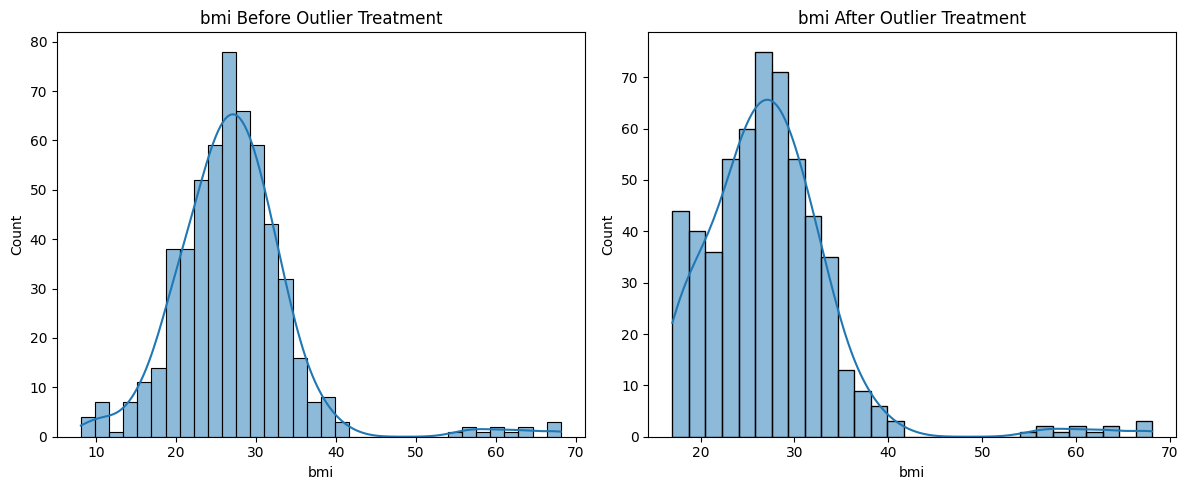

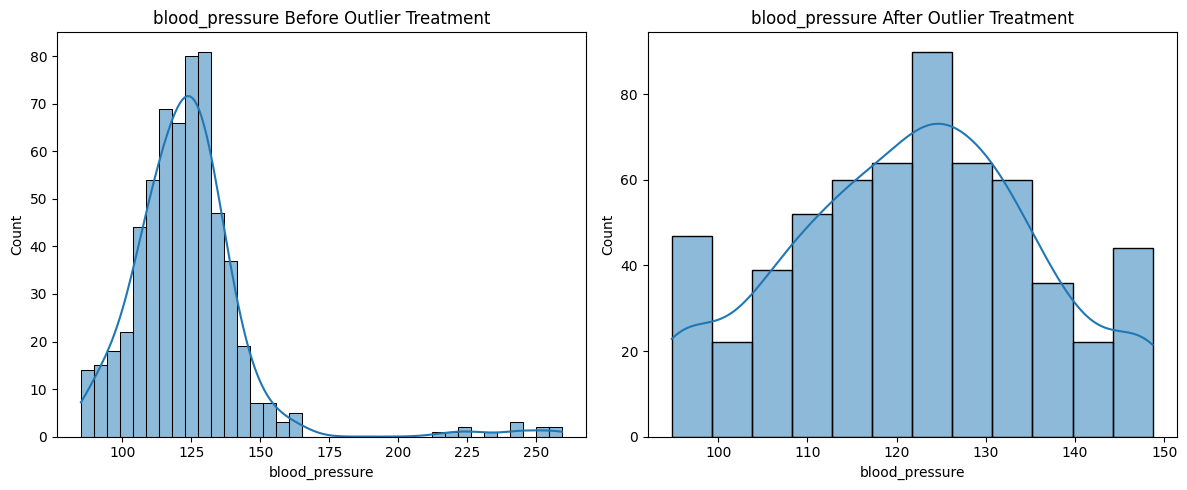

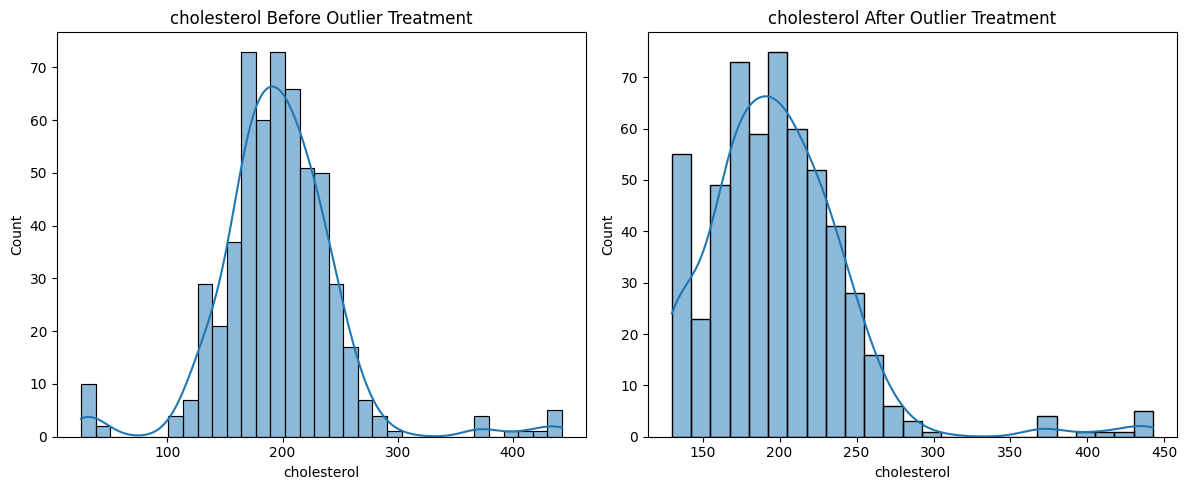

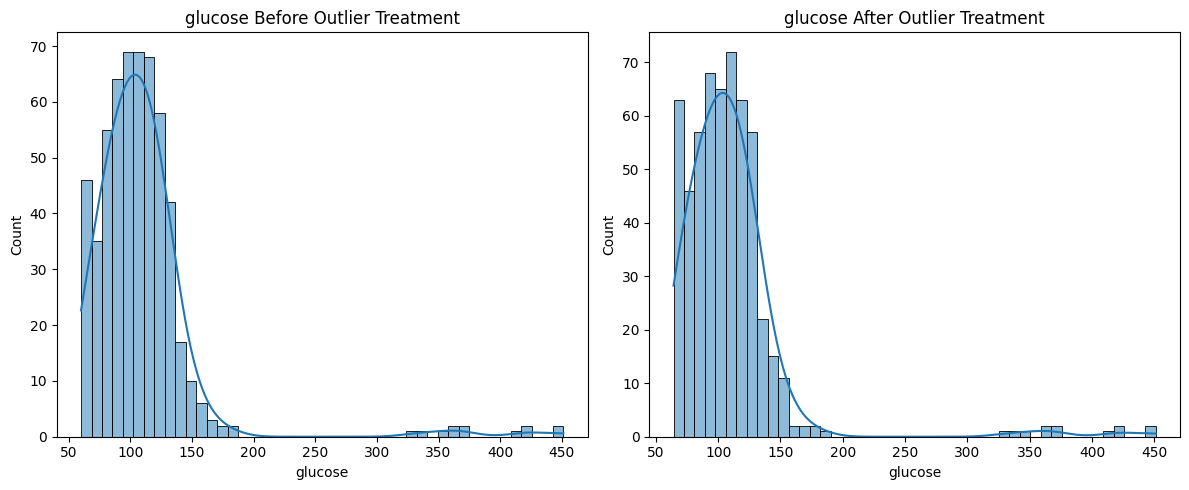

In [34]:
for col in percentile_columns:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Before Outlier Treatment')

    plt.subplot(1, 2, 2)
    sns.histplot(df_winsor[col], kde=True)
    plt.title(f'{col} After Outlier Treatment')
    plt.tight_layout()
    plt.savefig(f"{col}_before_after_winsorization.png", dpi=300, bbox_inches="tight")
    plt.show()

### Interpretation 
The histograms show the distribution of the selected numerical variables before and after outlier treatment. After winsorization, the extreme values are capped at the selected percentile limits. This reduces the influence of unusually high or low observations while preserving the total number of records. The overall distribution remains similar, but the extreme tails are reduced, making the data more suitable for further analysis and machine-learning models.

## PART - C Final Clean Dataset

In [35]:
# Create a separate dataframe for the final dataset
df_final = df.copy()

print("Original shape:", df.shape)
print("Final working dataset shape:", df_final.shape)

Original shape: (600, 9)
Final working dataset shape: (600, 9)


In [36]:
# Numerical columns with missing values
numeric_columns = ['age','bmi','blood_pressure','cholesterol','glucose']

mice_imputer = IterativeImputer(max_iter=10,random_state=42)
df_final[numeric_columns] = mice_imputer.fit_transform(df_final[numeric_columns])

print("Missing numerical values after MICE:")
print(df_final[numeric_columns].isnull().sum())

Missing numerical values after MICE:
age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
dtype: int64


In [37]:
# Categorical columns
categorical_columns = ['gender', 'region']

cat_imputer = SimpleImputer(strategy='most_frequent')
df_final[categorical_columns] = cat_imputer.fit_transform(df_final[categorical_columns])

print("Missing categorical values after imputation:")
print(df_final[categorical_columns].isnull().sum())

Missing categorical values after imputation:
gender    0
region    0
dtype: int64


In [38]:
# Columns selected for outlier treatment
outlier_columns = ['bmi','blood_pressure','cholesterol','glucose']

for col in outlier_columns:
    df_final[col] = np.array(
        winsorize(df_final[col],limits=[0.05, 0.05]))

print("Winsorization applied successfully.")

Winsorization applied successfully.


In [39]:
print("Missing values in final dataset:")
display(df_final.isnull().sum())

Missing values in final dataset:


patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64

In [40]:
print("Unique values in disease_risk:")
print(df_final['disease_risk'].unique())

print("\nDisease Risk Counts:")
print(df_final['disease_risk'].value_counts())

Unique values in disease_risk:
[1 0]

Disease Risk Counts:
disease_risk
0    372
1    228
Name: count, dtype: int64


In [41]:
print("Original Dataset:")
print(df.shape)

print("\nFinal Clean Dataset:")
print(df_final.shape)

print("\nTotal Missing Values - Original:")
print(df.isnull().sum().sum())

print("\nTotal Missing Values - Final:")
print(df_final.isnull().sum().sum())

Original Dataset:
(600, 9)

Final Clean Dataset:
(600, 9)

Total Missing Values - Original:
242

Total Missing Values - Final:
0


In [42]:
df_final.to_csv('final_clean_patient_dataset.csv',index=False)
print("Final clean dataset saved successfully.")

Final clean dataset saved successfully.


## Part C — Final Clean Dataset Interpretation

- The final dataset was created using the original dataset as a copy, so the original data remained unchanged.

- For numerical missing values, MICE was selected because it uses relationships between multiple numerical variables to estimate missing values. For categorical variables, most frequent imputation was used.

- Winsorization was selected for outlier treatment because it reduces the effect of extreme values without removing complete records from the dataset.

- After the cleaning process, missing values were handled appropriately and the dataset retained its original number of rows. The `disease_risk` variable was kept unchanged with binary values 0 and 1.

Therefore, the final dataset is cleaner, more consistent, and ready for further analysis or machine learning.
